In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [10]:
df.columns = df.columns.str.strip().str.lower()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.drop_duplicates()

df = df.dropna(subset=["event", "date", "linkid"])

df["country"] = df["country"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")

print("Dataset shape:", df.shape)
print(df.isnull().sum())

Dataset shape: (122567, 9)
event         0
date          0
country       0
city          0
artist       28
album         4
track         4
isrc       6306
linkid        0
dtype: int64


In [11]:
df["user_id"] = (
    df["country"].astype(str)
    + "_"
    + df["city"].astype(str)
)

df["session_id"] = (
    df["date"].astype(str)
    + "_"
    + df["country"].astype(str)
    + "_"
    + df["city"].astype(str)
    + "_"
    + df["linkid"].astype(str)
)

In [12]:
total_sessions = df["session_id"].nunique()
total_users = df["user_id"].nunique()

session_events = pd.crosstab(
    df["session_id"],
    df["event"]
)

for event in ["pageview", "preview", "click"]:
    if event not in session_events.columns:
        session_events[event] = 0

bounced_sessions = session_events[
    (session_events["pageview"] > 0)
    & (session_events["preview"] == 0)
    & (session_events["click"] == 0)
]

bounce_rate = (
    len(bounced_sessions) / total_sessions
) * 100

print("Total Sessions:", total_sessions)
print("Total Users:", total_users)
print("Bounce Rate:", round(bounce_rate, 2), "%")

Total Sessions: 74358
Total Users: 12478
Bounce Rate: 44.07 %


In [13]:
event_duration = {
    "pageview": 10,
    "preview": 30,
    "click": 20
}

df["estimated_seconds"] = df["event"].map(event_duration)

average_session_duration = (
    df.groupby("session_id")["estimated_seconds"]
    .sum()
    .mean()
)

print(
    "Estimated Average Session Duration:",
    round(average_session_duration, 2),
    "seconds"
)

Estimated Average Session Duration: 25.35 seconds


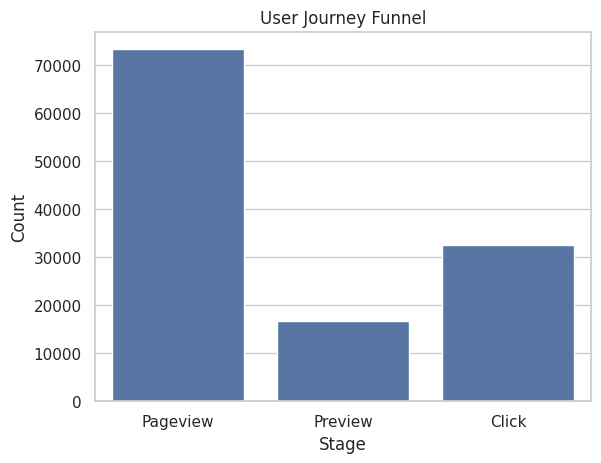

In [14]:
event_counts = df["event"].value_counts()

journey = pd.DataFrame({
    "Stage": ["Pageview", "Preview", "Click"],
    "Count": [
        event_counts.get("pageview", 0),
        event_counts.get("preview", 0),
        event_counts.get("click", 0)
    ]
})

sns.barplot(data=journey, x="Stage", y="Count")

plt.title("User Journey Funnel")
plt.show()

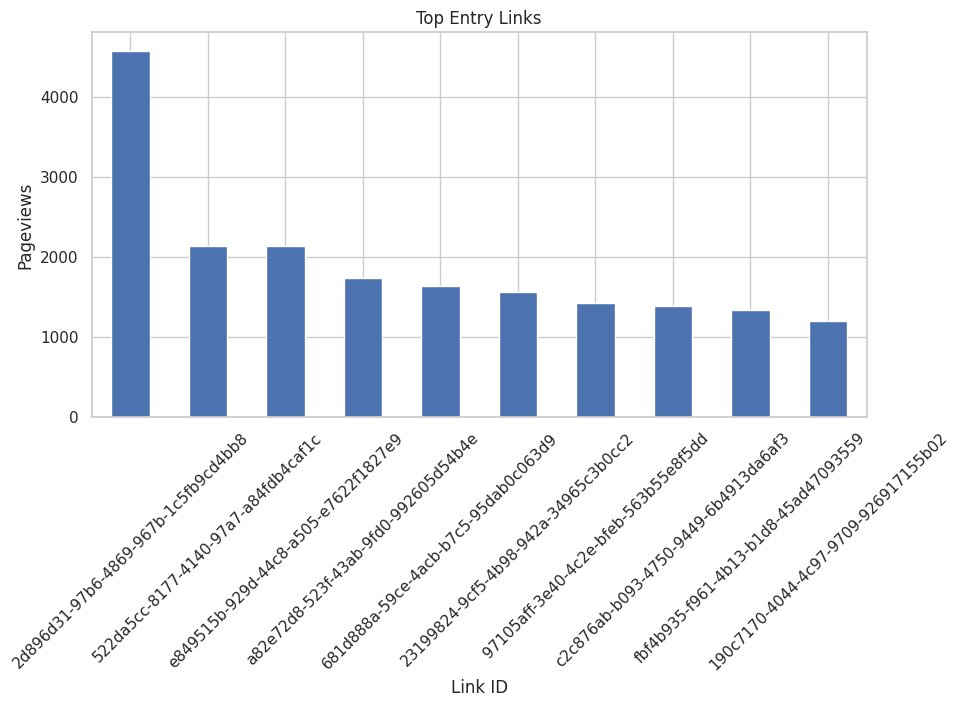

In [15]:
top_entry_pages = (
    df[df["event"] == "pageview"]["linkid"]
    .value_counts()
    .head(10)
)

top_entry_pages.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Entry Links")
plt.xlabel("Link ID")
plt.ylabel("Pageviews")
plt.xticks(rotation=45)
plt.show()

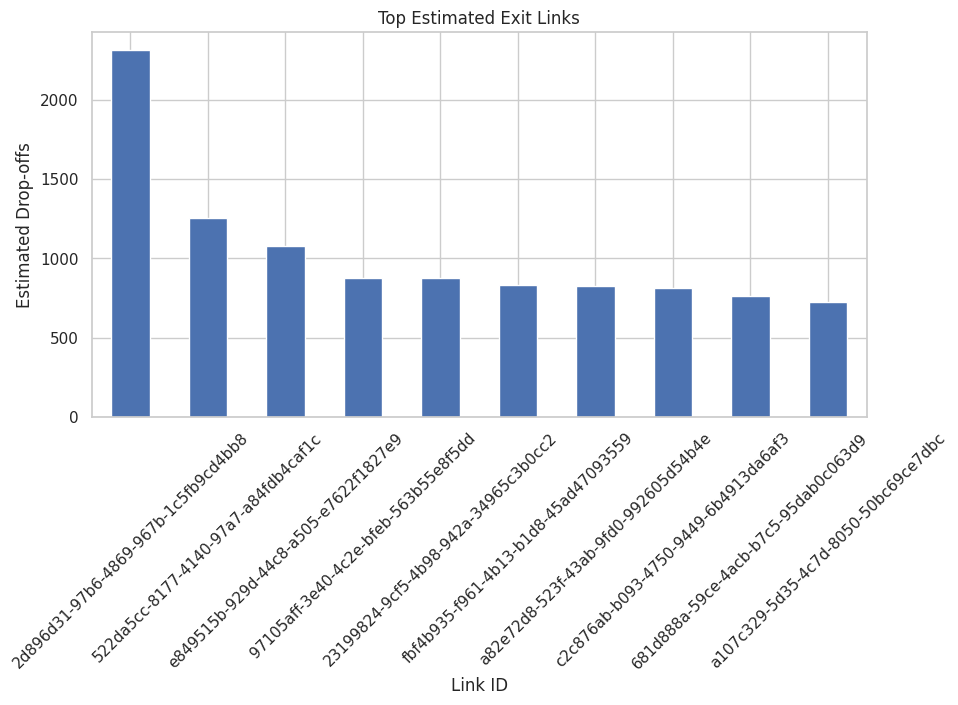

In [16]:
link_events = pd.crosstab(
    df["linkid"],
    df["event"]
)

for event in ["pageview", "click"]:
    if event not in link_events.columns:
        link_events[event] = 0

link_events["dropoffs"] = (
    link_events["pageview"]
    - link_events["click"]
)

top_exit_pages = (
    link_events
    .sort_values("dropoffs", ascending=False)
    .head(10)
)

top_exit_pages["dropoffs"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Estimated Exit Links")
plt.xlabel("Link ID")
plt.ylabel("Estimated Drop-offs")
plt.xticks(rotation=45)
plt.show()

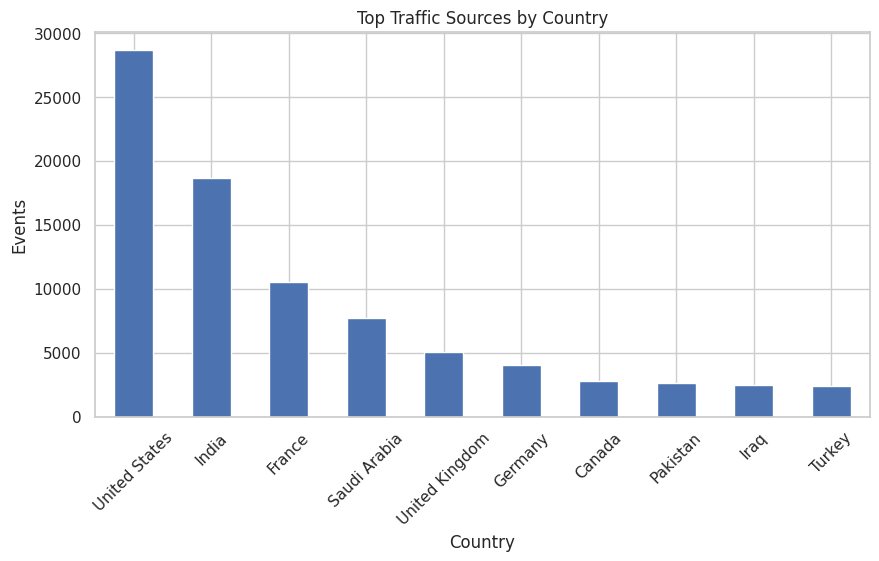

In [17]:
top_countries = df["country"].value_counts().head(10)

top_countries.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Traffic Sources by Country")
plt.xlabel("Country")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.show()

In [18]:
recommendations = [
    "Improve high-traffic links that generate very few clicks.",
    "Add clearer call-to-action buttons on landing pages.",
    "Reduce page load time and improve mobile responsiveness.",
    "Target countries and cities that generate the most traffic.",
    "Add referral source, session ID and timestamp tracking in future datasets."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

1. Improve high-traffic links that generate very few clicks.
2. Add clearer call-to-action buttons on landing pages.
3. Reduce page load time and improve mobile responsiveness.
4. Target countries and cities that generate the most traffic.
5. Add referral source, session ID and timestamp tracking in future datasets.
